# **Analyse de conversations sur la santé mentale**
**Étudiant :** Emin Belkheir 22204589

**ETAPE 1 :**  Exploration d'un jeu de données

**Source des données :** https://www.kaggle.com/datasets/thedevastator/nlp-mental-health-conversations

**GitHub** https://github.com/cypnet/Analyse-de-conversations-sur-la-sant-mentale-

**Résumé:** L'objectif de l'étape 1 du projet est d'analyser

# Import des bibliothèques utilisées qui seront utilisées pour l'étape 1 :

**Pandas :** Manipuler des données sous forme de tableau

**NumPy :** Calcul mathématiques

**MatPlotLib :** Graphique afin de visualiser les données

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Les bibliothèques ont bien été importées.")

Les bibliothèques ont bien été importées.


In [48]:
path_data = "./train.csv"
df = pd.read_csv(path_data)
print("Taille du fichier : ", df.shape)
print("Exemple de données : ", df.head(10))
print("Nom des colonnes : ", df.columns.tolist())


Taille du fichier :  (3512, 2)
Exemple de données :                                               Context  \
0  I'm going through some things with my feelings...   
1  I'm going through some things with my feelings...   
2  I'm going through some things with my feelings...   
3  I'm going through some things with my feelings...   
4  I'm going through some things with my feelings...   
5  I'm going through some things with my feelings...   
6  I'm going through some things with my feelings...   
7  I'm going through some things with my feelings...   
8  I'm going through some things with my feelings...   
9  I'm going through some things with my feelings...   

                                            Response  
0  If everyone thinks you're worthless, then mayb...  
1  Hello, and thank you for your question and see...  
2  First thing I'd suggest is getting the sleep y...  
3  Therapy is essential for those that are feelin...  
4  I first want to let you know that you are not ...  


In [49]:
# Nettoyage des données
# On peut voir qu'on a les mêmes questions avec plusieurs réponses différentes.
# On va supprimer les lignes vides et les données incomplètes.

df = df.dropna(how='all')
print("Taille du fichier après suppression des lignes vides : ", df.shape)

df = df.dropna(subset=['Context'])
print("Taille du fichier après suppression des lignes avec question vide : ", df.shape)

df = df.dropna(subset=['Response'])
df = df.reset_index(drop=True)  # Réinitialiser l'index après suppression
print("Taille du fichier après suppression des lignes avec réponse vide : ", df.shape)

Taille du fichier après suppression des lignes vides :  (3512, 2)
Taille du fichier après suppression des lignes avec question vide :  (3512, 2)
Taille du fichier après suppression des lignes avec réponse vide :  (3508, 2)


Nombre de questions de base :  3508
Nombre de réponses de base :  3508
Nombre de questions différentes :  995
Nombre de réponses différentes :  2479


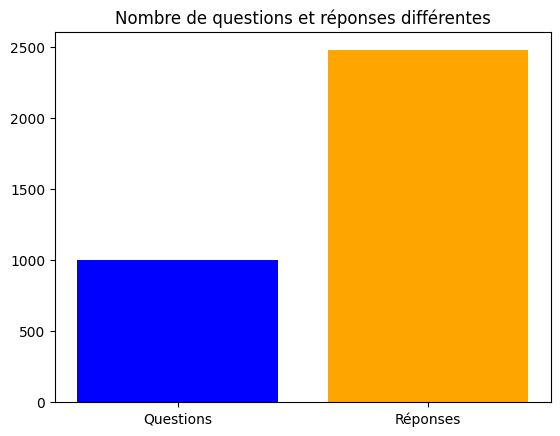

In [50]:
# Analyse du nombre de questions et réponses
# Compter le nombre total de questions et réponses
nb_questions_base = df['Context'].count()  # Nombre total de questions (valeurs non nulles)
nb_reponses_base = df['Response'].count()  # Nombre total de réponses (valeurs non nulles)
print("Nombre de questions de base : ", nb_questions_base)
print("Nombre de réponses de base : ", nb_reponses_base)

# Compter le nombre de questions et réponses uniques (sans doublons)
nb_questions = df['Context'].nunique()  # Nombre de questions différentes
nb_reponses = df['Response'].nunique()  # Nombre de réponses différentes
print("Nombre de questions différentes : ", nb_questions)
print("Nombre de réponses différentes : ", nb_reponses)

#Affichage du graphique pour le nombre de questions et réponses
labels = ['Questions', 'Réponses']
values = [nb_questions, nb_reponses]
plt.bar(labels, values, color=['blue', 'orange'])
plt.title('Nombre de questions et réponses différentes')
plt.show()


## Analyse de la distribution des réponses
Certaines questions reçoivent plus d'attention que d'autres. Nous allons calculer combien de réponses chaque question possède en moyenne.

Nombre maximum de réponses pour une seule question : 94
Nombre moyen de réponses par question : 3.53
Nombre median de réponses par question : 2.0
Ecart-type du nombre de réponses par question : 5.21
Question avec le plus de réponses : I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety. I have low self esteem but I’ve been happily married for almost 35 years.
   I’ve never had counseling about any of this. Do I have too many issues to address in counseling? (94 réponses)
Question avec le moins de réponses :  such as not enough sleep (1 réponse(s))


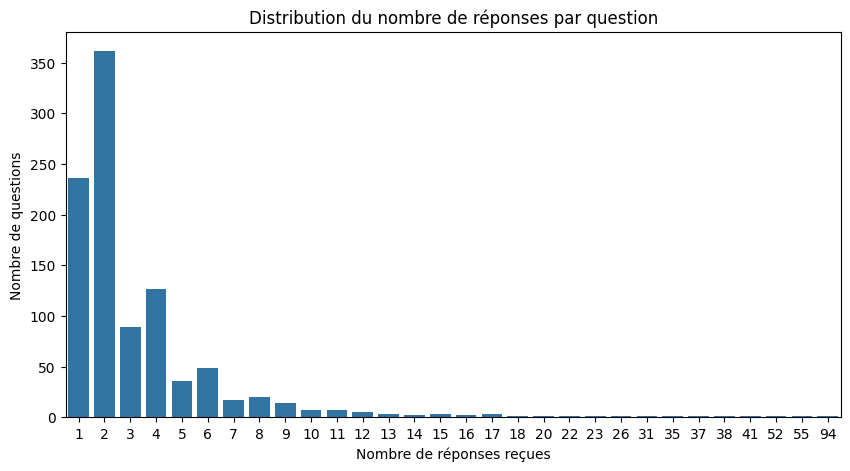

In [51]:
# On groupe par question et on compte le nombre de réponses
reponses_par_question = df.groupby('Context').count()['Response']

# Statistique descriptive
print(f"Nombre maximum de réponses pour une seule question : {reponses_par_question.max()}")
print(f"Nombre moyen de réponses par question : {reponses_par_question.mean():.2f}")
print(f"Nombre median de réponses par question : {reponses_par_question.median()}")
print(f"Ecart-type du nombre de réponses par question : {reponses_par_question.std():.2f}")

print(f"Question avec le plus de réponses : {reponses_par_question.idxmax()} ({reponses_par_question.max()} réponses)")
print(f"Question avec le moins de réponses : {reponses_par_question.idxmin()} ({reponses_par_question.min()} réponse(s))")

# Graphique de distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=reponses_par_question)
plt.title("Distribution du nombre de réponses par question")
plt.xlabel("Nombre de réponses reçues")
plt.ylabel("Nombre de questions")
plt.show()


## Tableau statistique récapitulatif
Résumé des statistiques principales du jeu de données.


In [52]:
# Calcul des statistiques
nb_patients = df['Context'].nunique()  # Nombre de patients uniques
nb_therapeutes = df['Response'].nunique()  # Nombre de réponses uniques (représentant les thérapeutes)
nb_conversations_total = len(df)  # Nombre total d'échanges
nb_echanges_moyen_par_conversation = df.groupby('Context').size().mean()

# DataFrame de statistiques
stats_data = {
    'Métrique': [
        'Nombre de patients (conversations uniques)',
        'Nombre de thérapeutes (réponses uniques)',
        'Nombre total d\'échanges',
        'Nombre moyen d\'échanges par conversation'
    ],
    'Valeur': [
        nb_patients,
        nb_therapeutes,
        nb_conversations_total,
        f"{nb_echanges_moyen_par_conversation:.2f}"
    ]
}

stats_df = pd.DataFrame(stats_data)

print("=" * 70)
print("TABLEAU STATISTIQUE RÉCAPITULATIF")
print("=" * 70)
print(stats_df.to_string(index=False))
print("=" * 70)


TABLEAU STATISTIQUE RÉCAPITULATIF
                                  Métrique Valeur
Nombre de patients (conversations uniques)    995
  Nombre de thérapeutes (réponses uniques)   2479
                   Nombre total d'échanges   3508
  Nombre moyen d'échanges par conversation   3.53
